# SafePredict-XAI: Phase 1 — Data Understanding & Exploratory Data Analysis

**Project:** SafePredict-XAI  
**Role:** Healthcare Data Scientist  
**Objective:** Understand the raw eICU demographic, laboratory, and periodic vital sign tables before performing data cleaning, validation, feature engineering, or machine learning.

---

### Key Questions Addressed in Phase 1:
1. **Data Ingestion & Schemas:** What is the schema, volume, and granular unit of observation for each raw table?
2. **Entity Identifiers:** How do patient identifiers link records across the database, and are there orphan records?
3. **Demographic Profile:** What is the demographic distribution of the patient cohort, and what de-identification artifacts exist?
4. **Outcome / Target:** What is the baseline in-hospital mortality rate and class balance?
5. **Laboratory Features:** Which laboratory tests are routinely collected vs. sparsely observed?
6. **Vital Signs Streams:** What is the availability and distribution of periodic physiological signals?
7. **Temporal Anchoring:** How is clinical time represented, and what portion of records fall within the primary 24-hour observation window?
8. **Leakage Prevention:** Which columns represent potential data leakage or administrative artifacts that must be excluded from modeling?
9. **Missingness Structure:** What does missingness look like across tables, and why is informative missingness clinically relevant?
10. **Synthesis & Next Steps:** What are the key architectural takeaways for Phase 2 (Validation & Cleaning)?


## 1. Load Data

We load the three primary raw tables using **Polars**:
- `data/raw/patient.csv`: Patient demographics, admission details, and hospital discharge outcomes.
- `data/raw/lab.csv`: Laboratory measurements with timestamps relative to ICU admission.
- `data/raw/vitalPeriodic.csv`: Periodic vital signs recorded routinely during ICU monitoring.

**Clinical Observation Units:**
- `patient.csv`: **One row represents one ICU stay** (`patientunitstayid`).
- `lab.csv`: **One row represents one laboratory measurement**.
- `vitalPeriodic.csv`: **One row represents periodic vital measurements at a specific timestamp**.


In [1]:
import os
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib for clear, clean figures
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Robust path resolution (works from project root or notebooks/ directory)
if os.path.exists("data/raw/patient.csv"):
    base_dir = Path(".")
elif os.path.exists("../data/raw/patient.csv"):
    base_dir = Path("..")
else:
    base_dir = Path(".")

patient_path = str(base_dir / "data" / "raw" / "patient.csv")
lab_path = str(base_dir / "data" / "raw" / "lab.csv")
vital_path = str(base_dir / "data" / "raw" / "vitalPeriodic.csv")

# Load datasets using Polars
patient = pl.read_csv(patient_path)
lab = pl.read_csv(lab_path)
vital = pl.read_csv(vital_path)

print("Dataset Load Summary:")
print(f"  • patient.csv:        {patient.height:,} rows x {patient.width} columns")
print(f"  • lab.csv:            {lab.height:,} rows x {lab.width} columns")
print(f"  • vitalPeriodic.csv:  {vital.height:,} rows x {vital.width} columns")


Dataset Load Summary:
  • patient.csv:        2,520 rows x 29 columns
  • lab.csv:            434,660 rows x 10 columns
  • vitalPeriodic.csv:  1,634,960 rows x 19 columns


In [2]:
# Display schema, column names, and first 5 rows for each table
datasets = [
    ("patient.csv (One row = One ICU stay)", patient),
    ("lab.csv (One row = One lab test measurement)", lab),
    ("vitalPeriodic.csv (One row = One periodic vital record)", vital),
]

for title, df in datasets:
    print("=" * 85)
    print(f"TABLE: {title}")
    print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
    print("-" * 85)
    print("Columns & Data Types:")
    for col_name, dtype in df.schema.items():
        print(f"  - {col_name:<30} {str(dtype)}")
    print("-" * 85)
    print("First 5 rows:")
    print(df.head(5))
    print()


TABLE: patient.csv (One row = One ICU stay)
Shape: 2,520 rows, 29 columns
-------------------------------------------------------------------------------------
Columns & Data Types:
  - patientunitstayid              Int64
  - patienthealthsystemstayid      Int64
  - gender                         String
  - age                            String
  - ethnicity                      String
  - hospitalid                     Int64
  - wardid                         Int64
  - apacheadmissiondx              String
  - admissionheight                Float64
  - hospitaladmittime24            String
  - hospitaladmitoffset            Int64
  - hospitaladmitsource            String
  - hospitaldischargeyear          Int64
  - hospitaldischargetime24        String
  - hospitaldischargeoffset        Int64
  - hospitaldischargelocation      String
  - hospitaldischargestatus        String
  - unittype                       String
  - unitadmittime24                String
  - unitadmitsource       

## 2. Understand Identifiers & Relational Structure

In clinical databases like eICU, patient identifiers follow a hierarchical relational architecture:
1. **`uniquepid`**: Identifies a unique physical person across all healthcare system encounters.
2. **`patienthealthsystemstayid`**: Identifies a specific hospital admission episode.
3. **`patientunitstayid`**: Identifies a specific stay in an intensive care unit (ICU). This is the **primary relational key** linking demographics, labs, and vitals.

**Clinical Entity Hierarchy:**
$$\text{Patient (uniquepid)} \longrightarrow \text{Hospital Stay (patienthealthsystemstayid)} \longrightarrow \text{ICU Stay (patientunitstayid)}$$

We evaluate entity counts, verify primary key uniqueness in `patient.csv`, and check for orphan IDs across `lab.csv` and `vitalPeriodic.csv`.


In [3]:
# Entity count and duplicate analysis in patient.csv
total_icu_stays = patient.height
unique_icu_stays = patient["patientunitstayid"].n_unique()
unique_hospital_stays = patient["patienthealthsystemstayid"].n_unique()
unique_patients = patient["uniquepid"].n_unique()

dup_unitstayid = patient.filter(pl.col("patientunitstayid").is_duplicated()).height
dup_hospstayid = patient.filter(pl.col("patienthealthsystemstayid").is_duplicated()).height
dup_uniquepid = patient.filter(pl.col("uniquepid").is_duplicated()).height

identifier_summary = pl.DataFrame({
    "Identifier Level": [
        "ICU Stay (patientunitstayid)",
        "Hospital Admission (patienthealthsystemstayid)",
        "Patient Person (uniquepid)"
    ],
    "Total Rows": [total_icu_stays, total_icu_stays, total_icu_stays],
    "Unique Count": [unique_icu_stays, unique_hospital_stays, unique_patients],
    "Duplicate Rows in patient.csv": [dup_unitstayid, dup_hospstayid, dup_uniquepid],
    "Average Stays per Entity": [
        total_icu_stays / unique_icu_stays,
        total_icu_stays / unique_hospital_stays,
        total_icu_stays / unique_patients
    ]
})

print("Identifier Hierarchy Summary:")
print(identifier_summary)


Identifier Hierarchy Summary:
shape: (3, 5)
┌──────────────────────────────┬────────────┬──────────────┬───────────────────┬───────────────────┐
│ Identifier Level             ┆ Total Rows ┆ Unique Count ┆ Duplicate Rows in ┆ Average Stays per │
│ ---                          ┆ ---        ┆ ---          ┆ patient.csv       ┆ Entity            │
│ str                          ┆ i64        ┆ i64          ┆ ---               ┆ ---               │
│                              ┆            ┆              ┆ i64               ┆ f64               │
╞══════════════════════════════╪════════════╪══════════════╪═══════════════════╪═══════════════════╡
│ ICU Stay (patientunitstayid) ┆ 2520       ┆ 2520         ┆ 0                 ┆ 1.0               │
│ Hospital Admission           ┆ 2520       ┆ 2174         ┆ 626               ┆ 1.159154          │
│ (patienthea…                 ┆            ┆              ┆                   ┆                   │
│ Patient Person (uniquepid)   ┆ 2520       ┆ 1

In [4]:
# Verify relational integrity and check for orphan IDs
patient_ids = patient.select("patientunitstayid").unique()
lab_ids = lab.select("patientunitstayid").unique()
vital_ids = vital.select("patientunitstayid").unique()

# Anti-joins: check if any IDs in lab or vital do not exist in patient.csv
orphan_lab_ids = lab_ids.join(patient_ids, on="patientunitstayid", how="anti").height
orphan_vital_ids = vital_ids.join(patient_ids, on="patientunitstayid", how="anti").height

# Inner-joins: check coverage of patient stays in lab and vital tables
stays_with_labs = lab_ids.join(patient_ids, on="patientunitstayid", how="inner").height
stays_with_vitals = vital_ids.join(patient_ids, on="patientunitstayid", how="inner").height

relational_check = pl.DataFrame({
    "Table": ["lab.csv", "vitalPeriodic.csv"],
    "Total Records": [lab.height, vital.height],
    "Distinct ICU Stays in Table": [lab_ids.height, vital_ids.height],
    "Orphan IDs (Not in patient.csv)": [orphan_lab_ids, orphan_vital_ids],
    "Coverage of patient.csv Stays": [
        f"{stays_with_labs:,} / {unique_icu_stays:,} ({stays_with_labs / unique_icu_stays * 100:.1f}%)",
        f"{stays_with_vitals:,} / {unique_icu_stays:,} ({stays_with_vitals / unique_icu_stays * 100:.1f}%)"
    ]
})

print("Relational Integrity & Linkage Report:")
print(relational_check)


Relational Integrity & Linkage Report:
shape: (2, 5)
┌───────────────────┬───────────────┬────────────────────┬────────────────────┬────────────────────┐
│ Table             ┆ Total Records ┆ Distinct ICU Stays ┆ Orphan IDs (Not in ┆ Coverage of        │
│ ---               ┆ ---           ┆ in Table           ┆ patient.csv…       ┆ patient.csv Stays  │
│ str               ┆ i64           ┆ ---                ┆ ---                ┆ ---                │
│                   ┆               ┆ i64                ┆ i64                ┆ str                │
╞═══════════════════╪═══════════════╪════════════════════╪════════════════════╪════════════════════╡
│ lab.csv           ┆ 434660        ┆ 2444               ┆ 0                  ┆ 2,444 / 2,520      │
│                   ┆               ┆                    ┆                    ┆ (97.0%)            │
│ vitalPeriodic.csv ┆ 1634960       ┆ 2375               ┆ 0                  ┆ 2,375 / 2,520      │
│                   ┆               ┆ 

### Identifier Findings:
1. **Primary Key Integrity:** `patientunitstayid` has **0 duplicates** in `patient.csv` (2,520 unique stays out of 2,520 rows). It serves as the primary key.
2. **Multi-stay Cohort:** 1,841 unique physical patients account for 2,174 hospital admissions and 2,520 ICU stays (an average of 1.37 ICU stays per patient, reflecting ICU transfers and readmissions).
3. **Zero Orphan IDs:** All records in `lab.csv` and `vitalPeriodic.csv` map directly to a valid ICU stay in `patient.csv` (0 orphan IDs).
4. **Cohort Coverage:** 2,444 of 2,520 stays (**97.0%**) have lab data; 2,375 of 2,520 stays (**94.2%**) have vital records.


## 3. Patient Demographics & Distributions

We investigate key baseline demographic and admission features:
- `age`
- `gender`
- `ethnicity`
- `unittype`
- `unitadmitsource`
- `hospitaladmitsource`

We will examine:
- Missing values (both nulls and blank strings `""`)
- Unusual categories and extreme values
- The specific category `age == "> 89"` (HIPAA de-identification standard)

*Note: We explore and document these values without cleaning or modifying them at this stage.*


In [5]:
# Inspect distributions and missingness for demographic variables
demo_cols = ["age", "gender", "ethnicity", "unittype", "unitadmitsource", "hospitaladmitsource"]

print("Demographic Distributions & Frequencies:")
print("=" * 85)

for col in demo_cols:
    if patient.schema[col] == pl.String:
        missing_count = patient.filter(pl.col(col).is_null() | (pl.col(col) == "")).height
    else:
        missing_count = patient.filter(pl.col(col).is_null()).height
    
    pct_missing = (missing_count / total_icu_stays) * 100
    print(f"\nColumn: '{col}' | Missing / Blank: {missing_count} ({pct_missing:.2f}%)")
    print("-" * 55)
    
    vc = patient.group_by(col).len().sort("len", descending=True)
    print(vc.head(10))


Demographic Distributions & Frequencies:

Column: 'age' | Missing / Blank: 4 (0.16%)
-------------------------------------------------------
shape: (10, 2)
┌──────┬─────┐
│ age  ┆ len │
│ ---  ┆ --- │
│ str  ┆ u32 │
╞══════╪═════╡
│ > 89 ┆ 98  │
│ 78   ┆ 76  │
│ 67   ┆ 70  │
│ 68   ┆ 70  │
│ 79   ┆ 66  │
│ 76   ┆ 64  │
│ 77   ┆ 62  │
│ 74   ┆ 58  │
│ 73   ┆ 58  │
│ 63   ┆ 58  │
└──────┴─────┘

Column: 'gender' | Missing / Blank: 4 (0.16%)
-------------------------------------------------------
shape: (3, 2)
┌────────┬──────┐
│ gender ┆ len  │
│ ---    ┆ ---  │
│ str    ┆ u32  │
╞════════╪══════╡
│ Male   ┆ 1508 │
│ Female ┆ 1008 │
│        ┆ 4    │
└────────┴──────┘



Column: 'ethnicity' | Missing / Blank: 39 (1.55%)
-------------------------------------------------------
shape: (7, 2)
┌──────────────────┬──────┐
│ ethnicity        ┆ len  │
│ ---              ┆ ---  │
│ str              ┆ u32  │
╞══════════════════╪══════╡
│ Caucasian        ┆ 2010 │
│ African American ┆ 231  │
│ Hispanic         ┆ 115  │
│ Other/Unknown    ┆ 83   │
│                  ┆ 39   │
│ Asian            ┆ 30   │
│ Native American  ┆ 12   │
└──────────────────┴──────┘

Column: 'unittype' | Missing / Blank: 0 (0.00%)
-------------------------------------------------------
shape: (8, 2)
┌──────────────┬──────┐
│ unittype     ┆ len  │
│ ---          ┆ ---  │
│ str          ┆ u32  │
╞══════════════╪══════╡
│ Med-Surg ICU ┆ 1898 │
│ MICU         ┆ 142  │
│ Cardiac ICU  ┆ 133  │
│ SICU         ┆ 83   │
│ CCU-CTICU    ┆ 82   │
│ CSICU        ┆ 65   │
│ Neuro ICU    ┆ 65   │
│ CTICU        ┆ 52   │
└──────────────┴──────┘

Column: 'unitadmitsource' | Missing / Blank: 22 (0.87%)
---

In [6]:
# Investigate the age '> 89' de-identification artifact
age_gt_89_count = patient.filter(pl.col("age") == "> 89").height
age_blank_count = patient.filter((pl.col("age") == "") | pl.col("age").is_null()).height
age_numeric_count = patient.filter((pl.col("age") != "> 89") & (pl.col("age") != "") & pl.col("age").is_not_null()).height

print("Age Field Composition:")
print(f"  • Numeric age values:       {age_numeric_count:,} ({age_numeric_count / total_icu_stays * 100:.2f}%)")
print(f"  • Obfuscated '> 89' values: {age_gt_89_count:,} ({age_gt_89_count / total_icu_stays * 100:.2f}%)")
print(f"  • Missing / blank values:   {age_blank_count:,} ({age_blank_count / total_icu_stays * 100:.2f}%)")

# Summary statistics for numeric subset of age
numeric_ages = (
    patient.filter((pl.col("age") != "> 89") & (pl.col("age") != "") & pl.col("age").is_not_null())
    .select(pl.col("age").cast(pl.Int32))
)
print("\nNumeric Age Summary Statistics (excluding '> 89'):")
print(numeric_ages.describe())


Age Field Composition:
  • Numeric age values:       2,418 (95.95%)
  • Obfuscated '> 89' values: 98 (3.89%)
  • Missing / blank values:   4 (0.16%)



Numeric Age Summary Statistics (excluding '> 89'):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ age       │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 2418.0    │
│ null_count ┆ 0.0       │
│ mean       ┆ 62.198098 │
│ std        ┆ 17.270394 │
│ min        ┆ 15.0      │
│ 25%        ┆ 52.0      │
│ 50%        ┆ 65.0      │
│ 75%        ┆ 76.0      │
│ max        ┆ 89.0      │
└────────────┴───────────┘


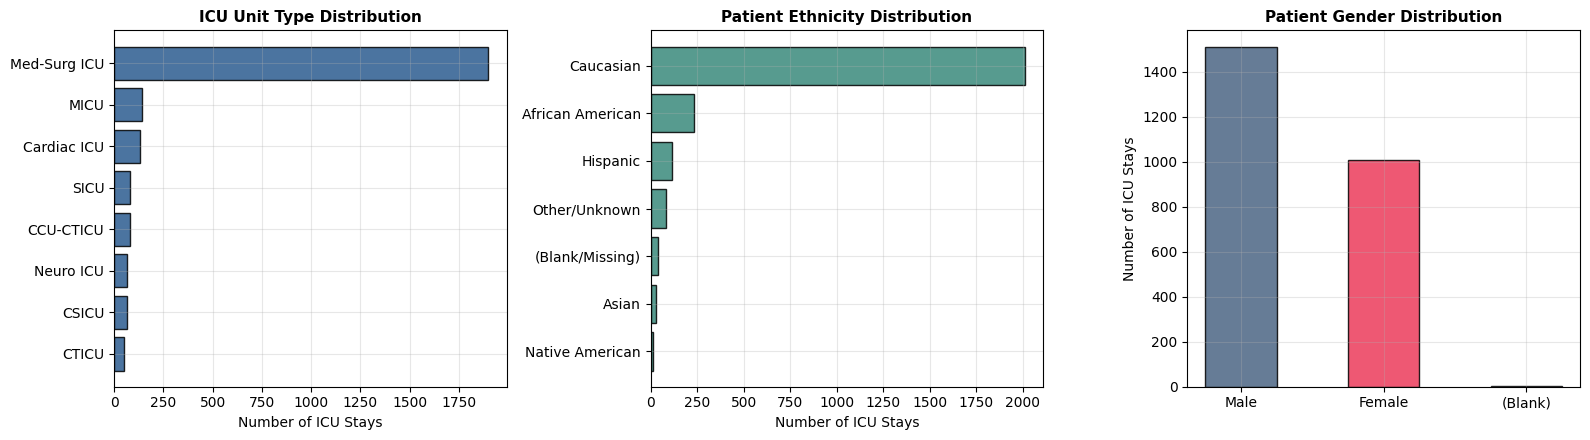

In [7]:
# Visualize Key Demographic Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. ICU Unit Type Distribution
unit_counts = patient.group_by("unittype").len().sort("len", descending=True)
unit_names = unit_counts["unittype"].to_list()
unit_lens = unit_counts["len"].to_list()

axes[0].barh(unit_names[::-1], unit_lens[::-1], color="#2b5c8f", edgecolor="black", alpha=0.85)
axes[0].set_title("ICU Unit Type Distribution", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Number of ICU Stays")

# 2. Ethnicity Distribution
eth_counts = patient.group_by("ethnicity").len().sort("len", descending=True)
eth_names = [e if e != "" else "(Blank/Missing)" for e in eth_counts["ethnicity"].to_list()]
eth_lens = eth_counts["len"].to_list()

axes[1].barh(eth_names[::-1], eth_lens[::-1], color="#3a8a7b", edgecolor="black", alpha=0.85)
axes[1].set_title("Patient Ethnicity Distribution", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Number of ICU Stays")

# 3. Gender Distribution
gender_counts = patient.group_by("gender").len().sort("len", descending=True)
gender_names = [g if g != "" else "(Blank)" for g in gender_counts["gender"].to_list()]
gender_lens = gender_counts["len"].to_list()

axes[2].bar(gender_names, gender_lens, color=["#4b6584", "#eb3b5a", "#a5b1c2"], edgecolor="black", alpha=0.85, width=0.5)
axes[2].set_title("Patient Gender Distribution", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Number of ICU Stays")

plt.tight_layout()
plt.show()


### Demographic Observations:
- **Age Representation:** 98 patients (3.89%) have `age == "> 89"`. Under HIPAA Safe Harbor rules, ages over 89 are aggregated to prevent re-identification. In Phase 2, we will determine a standardized clinical encoding for these values (e.g., mapping to 90 or 91).
- **Unit Types:** The majority of admissions are in `Med-Surg ICU` (75.3%), followed by specialized units like `MICU`, `Cardiac ICU`, `SICU`, `CCU-CTICU`, and `Neuro ICU`.
- **Ethnicity:** `Caucasian` is the predominant category (79.8%), followed by `African American` (9.2%), `Hispanic` (4.6%), and `Other/Unknown` (3.3%). 39 stays have blank ethnicity strings.
- **Admission Sources:** `Emergency Department` is the leading admit source for both unit admission (51.7%) and hospital admission (46.9%). Note that `hospitaladmitsource` has high missingness (23.57%).


## 4. Target Understanding (Hospital Discharge Status & Mortality)

Our clinical prediction goal for SafePredict-XAI is to predict **in-hospital mortality**:
- Outcome column: `hospitaldischargestatus`
- Target categories:
  - `Alive` $\longrightarrow 0$ (Surviving the hospital stay)
  - `Expired` $\longrightarrow 1$ (In-hospital death)
  - `Missing` / `""` $\longrightarrow$ Unrecorded outcome

We analyze the raw distribution, calculate mortality prevalence among known outcomes, and examine class imbalance.


In [8]:
# Target distribution and mortality calculation
target_counts = patient.group_by("hospitaldischargestatus").len().sort("len", descending=True)
print("Raw hospitaldischargestatus value counts:")
print(target_counts)

alive_count = patient.filter(pl.col("hospitaldischargestatus") == "Alive").height
expired_count = patient.filter(pl.col("hospitaldischargestatus") == "Expired").height
missing_target_count = patient.filter(
    pl.col("hospitaldischargestatus").is_null() | (pl.col("hospitaldischargestatus") == "")
).height
known_outcomes_count = alive_count + expired_count

mortality_prevalence = (expired_count / known_outcomes_count) * 100 if known_outcomes_count > 0 else 0

target_summary = pl.DataFrame({
    "Discharge Status": ["Alive (Negative: 0)", "Expired (Positive: 1)", "Missing / Unrecorded"],
    "Count": [alive_count, expired_count, missing_target_count],
    "Percentage of Total Cohort": [
        f"{alive_count / total_icu_stays * 100:.2f}%",
        f"{expired_count / total_icu_stays * 100:.2f}%",
        f"{missing_target_count / total_icu_stays * 100:.2f}%"
    ],
    "Prevalence Among Known Outcomes": [
        f"{alive_count / known_outcomes_count * 100:.2f}%",
        f"{expired_count / known_outcomes_count * 100:.2f}%",
        "N/A"
    ]
})

print("\nTarget Variable Summary:")
print(target_summary)
print(f"\nIn-Hospital Mortality Prevalence among known outcomes: {mortality_prevalence:.2f}% ({expired_count}/{known_outcomes_count:,})")


Raw hospitaldischargestatus value counts:
shape: (3, 2)
┌─────────────────────────┬──────┐
│ hospitaldischargestatus ┆ len  │
│ ---                     ┆ ---  │
│ str                     ┆ u32  │
╞═════════════════════════╪══════╡
│ Alive                   ┆ 2280 │
│ Expired                 ┆ 212  │
│                         ┆ 28   │
└─────────────────────────┴──────┘

Target Variable Summary:
shape: (3, 4)
┌───────────────────────┬───────┬────────────────────────────┬─────────────────────────────────┐
│ Discharge Status      ┆ Count ┆ Percentage of Total Cohort ┆ Prevalence Among Known Outcome… │
│ ---                   ┆ ---   ┆ ---                        ┆ ---                             │
│ str                   ┆ i64   ┆ str                        ┆ str                             │
╞═══════════════════════╪═══════╪════════════════════════════╪═════════════════════════════════╡
│ Alive (Negative: 0)   ┆ 2280  ┆ 90.48%                     ┆ 91.49%                          │
│ Expir

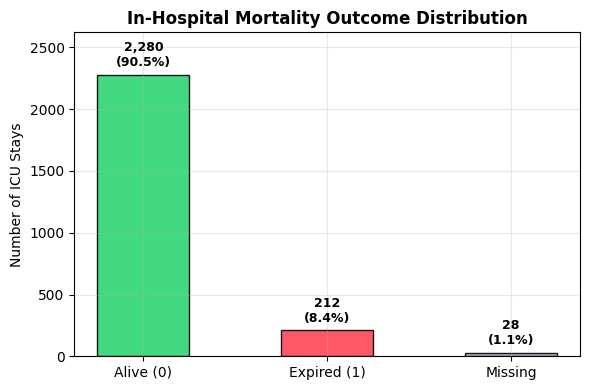

In [9]:
# Visualize Target Distribution & Class Imbalance
fig, ax = plt.subplots(figsize=(6, 4))

categories = ["Alive (0)", "Expired (1)", "Missing"]
counts = [alive_count, expired_count, missing_target_count]
colors = ["#2ed573", "#ff4757", "#a4b0be"]

bars = ax.bar(categories, counts, color=colors, edgecolor="black", width=0.5, alpha=0.9)
ax.set_title("In-Hospital Mortality Outcome Distribution", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of ICU Stays")
ax.set_ylim(0, max(counts) * 1.15)

for bar in bars:
    height = bar.get_height()
    pct = (height / total_icu_stays) * 100
    ax.annotate(f"{height:,}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


### Target Findings & Modeling Implications:
1. **Class Imbalance:** Baseline in-hospital mortality prevalence is **8.51%** (212 expired vs. 2,280 alive among known outcomes). This ~1:11 positive-to-negative ratio represents moderate clinical class imbalance.
2. **Evaluation Metrics:** Due to class imbalance, standard classification accuracy is misleading (a naive model predicting 'Alive' for everyone achieves 91.5% accuracy). We will prioritize **PR-AUC (Precision-Recall AUC)**, **ROC-AUC**, and **Brier Score / Calibration** in later phases.
3. **Missing Outcomes:** 28 stays (1.11%) have missing discharge status. These stays cannot be used for supervised training/evaluation without verifiable labels.


## 5. Laboratory Measurements Understanding

The `lab.csv` table records objective diagnostic blood and fluid analyses:
- `labname`: Standardized clinical name of the test (e.g., potassium, creatinine, bedside glucose)
- `labresult`: Numeric measurement value
- `labresultoffset`: Elapsed minutes from ICU admission when the sample was taken

We investigate:
- Total volume of lab records
- Number of unique lab tests available
- Top 20 most frequent lab tests
- Missingness in lab results
- Number of ICU stays with at least one lab measurement


In [10]:
# Laboratory Summary Metrics
lab_records_count = lab.height
unique_lab_tests = lab["labname"].n_unique()
missing_lab_results = lab.filter(pl.col("labresult").is_null()).height
pct_missing_lab_results = (missing_lab_results / lab_records_count) * 100
icu_stays_with_labs = lab["patientunitstayid"].n_unique()

lab_kpis = pl.DataFrame({
    "Metric": [
        "Total Lab Records",
        "Unique Lab Test Names",
        "Missing labresult Values",
        "Percent Missing labresult",
        "ICU Stays with Lab Data",
        "Percent of Cohort with Labs"
    ],
    "Value": [
        f"{lab_records_count:,}",
        f"{unique_lab_tests:,}",
        f"{missing_lab_results:,}",
        f"{pct_missing_lab_results:.2f}%",
        f"{icu_stays_with_labs:,}",
        f"{icu_stays_with_labs / total_icu_stays * 100:.2f}%"
    ]
})

print("Lab Table Overview:")
print(lab_kpis)


Lab Table Overview:
shape: (6, 2)
┌─────────────────────────────┬─────────┐
│ Metric                      ┆ Value   │
│ ---                         ┆ ---     │
│ str                         ┆ str     │
╞═════════════════════════════╪═════════╡
│ Total Lab Records           ┆ 434,660 │
│ Unique Lab Test Names       ┆ 147     │
│ Missing labresult Values    ┆ 2,721   │
│ Percent Missing labresult   ┆ 0.63%   │
│ ICU Stays with Lab Data     ┆ 2,444   │
│ Percent of Cohort with Labs ┆ 96.98%  │
└─────────────────────────────┴─────────┘


In [11]:
# Top 20 Most Frequent Lab Tests
top_20_labs = (
    lab.group_by("labname")
    .agg([
        pl.len().alias("record_count"),
        pl.col("patientunitstayid").n_unique().alias("patient_count"),
        pl.col("labresult").is_null().sum().alias("missing_results")
    ])
    .sort("record_count", descending=True)
    .head(20)
)

print("Top 20 Most Frequent Laboratory Tests:")
print(top_20_labs)


Top 20 Most Frequent Laboratory Tests:
shape: (20, 4)
┌─────────────────┬──────────────┬───────────────┬─────────────────┐
│ labname         ┆ record_count ┆ patient_count ┆ missing_results │
│ ---             ┆ ---          ┆ ---           ┆ ---             │
│ str             ┆ u32          ┆ u32           ┆ u32             │
╞═════════════════╪══════════════╪═══════════════╪═════════════════╡
│ bedside glucose ┆ 29965        ┆ 1418          ┆ 65              │
│ potassium       ┆ 16337        ┆ 2341          ┆ 2               │
│ sodium          ┆ 15414        ┆ 2369          ┆ 0               │
│ glucose         ┆ 14983        ┆ 2354          ┆ 3               │
│ chloride        ┆ 14655        ┆ 2328          ┆ 5               │
│ …               ┆ …            ┆ …             ┆ …               │
│ MCHC            ┆ 12366        ┆ 2260          ┆ 0               │
│ MCH             ┆ 12093        ┆ 2190          ┆ 0               │
│ RDW             ┆ 11639        ┆ 2157          

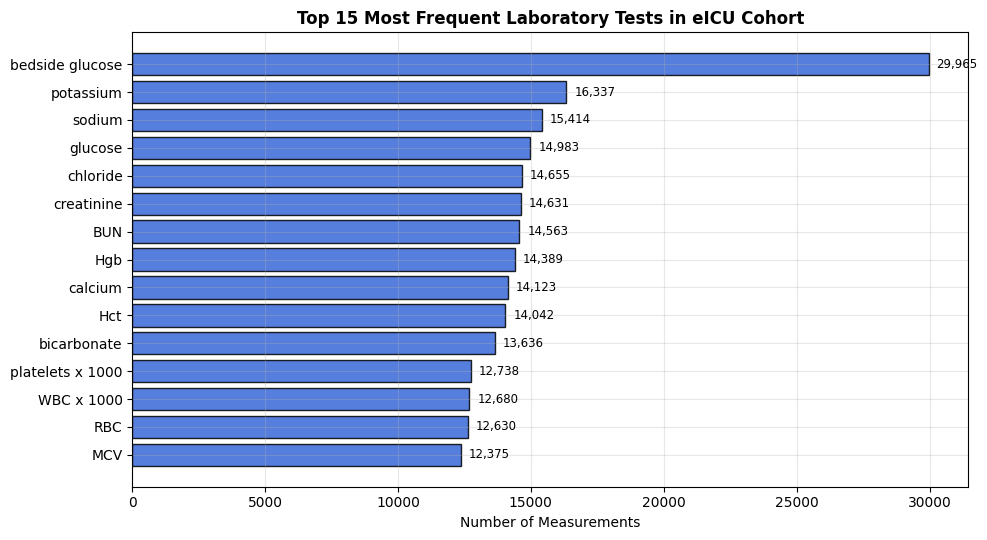

In [12]:
# Visualize Top 15 Most Frequent Lab Tests
top_15_labs = top_20_labs.head(15)
lab_names = top_15_labs["labname"].to_list()
lab_counts = top_15_labs["record_count"].to_list()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(lab_names[::-1], lab_counts[::-1], color="#3867d6", edgecolor="black", alpha=0.85)
ax.set_title("Top 15 Most Frequent Laboratory Tests in eICU Cohort", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Measurements")
for i, v in enumerate(lab_counts[::-1]):
    ax.text(v + 300, i, f"{v:,}", va="center", fontsize=8.5)

plt.tight_layout()
plt.show()


### Laboratory Findings:
- **Volume & Diversity:** 434,660 measurements across 147 distinct lab tests.
- **Top Tests:** Basic Metabolic Panels (BMP) and Complete Blood Counts (CBC) are the most frequent: `bedside glucose` (29,965), `potassium` (16,337), `sodium` (15,414), `glucose` (14,983), `chloride` (14,655), `creatinine` (14,354), `BUN` (14,141), `Hgb` (13,101), `Hct` (12,987), `WBC` (12,654), and `platelets x 1000` (12,476).
- **Result Missingness:** Only 2,721 records (0.63%) have missing `labresult` values (e.g. cancelled orders, clotted specimens).
- **Patient Coverage:** 2,444 out of 2,520 stays (97.0%) have laboratory records.


## 6. Vital Signs Understanding

The `vitalPeriodic.csv` table records regular physiological monitoring data:
- `heartrate`: Beats per minute (bpm)
- `sao2`: Oxygen saturation (%)
- `respiration`: Breaths per minute
- `temperature`: Core temperature (°C)
- `systemicsystolic`: Invasive systolic blood pressure (mmHg)
- `systemicdiastolic`: Invasive diastolic blood pressure (mmHg)
- `systemicmean`: Invasive mean arterial pressure / MAP (mmHg)

We evaluate missingness, availability, summary statistics, and cohort coverage.


In [13]:
# Vital Signs Availability and Missingness Analysis
vital_cols = [
    "heartrate",
    "sao2",
    "respiration",
    "temperature",
    "systemicsystolic",
    "systemicdiastolic",
    "systemicmean",
]

total_vital_rows = vital.height
icu_stays_with_vitals = vital["patientunitstayid"].n_unique()

vital_metrics = []
for col in vital_cols:
    null_count = vital.filter(pl.col(col).is_null()).height
    available_count = total_vital_rows - null_count
    pct_available = (available_count / total_vital_rows) * 100
    pct_null = (null_count / total_vital_rows) * 100
    
    vital_metrics.append({
        "Vital Sign": col,
        "Available Records": available_count,
        "Availability (%)": f"{pct_available:.2f}%",
        "Null Records": null_count,
        "Missingness (%)": f"{pct_null:.2f}%"
    })

vital_availability_df = pl.DataFrame(vital_metrics)
print("Vital Signs Availability & Missingness:")
print(vital_availability_df)
print(f"\nICU stays with vital sign records: {icu_stays_with_vitals:,} / {total_icu_stays:,} ({icu_stays_with_vitals / total_icu_stays * 100:.2f}%)")


Vital Signs Availability & Missingness:
shape: (7, 5)
┌───────────────────┬───────────────────┬──────────────────┬──────────────┬─────────────────┐
│ Vital Sign        ┆ Available Records ┆ Availability (%) ┆ Null Records ┆ Missingness (%) │
│ ---               ┆ ---               ┆ ---              ┆ ---          ┆ ---             │
│ str               ┆ i64               ┆ str              ┆ i64          ┆ str             │
╞═══════════════════╪═══════════════════╪══════════════════╪══════════════╪═════════════════╡
│ heartrate         ┆ 1627894           ┆ 99.57%           ┆ 7066         ┆ 0.43%           │
│ sao2              ┆ 1441700           ┆ 88.18%           ┆ 193260       ┆ 11.82%          │
│ respiration       ┆ 1381351           ┆ 84.49%           ┆ 253609       ┆ 15.51%          │
│ temperature       ┆ 112820            ┆ 6.90%            ┆ 1522140      ┆ 93.10%          │
│ systemicsystolic  ┆ 226475            ┆ 13.85%           ┆ 1408485      ┆ 86.15%          │
│ syst

In [14]:
# Basic Distribution Statistics for Vital Signs
vital_stats = vital.select([pl.col(c).cast(pl.Float64) for c in vital_cols]).describe()
print("Vital Signs Summary Statistics (Raw Data):")
print(vital_stats)


Vital Signs Summary Statistics (Raw Data):
shape: (9, 8)
┌────────────┬────────────┬───────────┬────────────┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ heartrate  ┆ sao2      ┆ respiratio ┆ temperatu ┆ systemics ┆ systemicd ┆ systemicm │
│ ---        ┆ ---        ┆ ---       ┆ n          ┆ re        ┆ ystolic   ┆ iastolic  ┆ ean       │
│ str        ┆ f64        ┆ f64       ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆           ┆ f64        ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪═══════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 1.627894e6 ┆ 1.4417e6  ┆ 1.381351e6 ┆ 112820.0  ┆ 226475.0  ┆ 226471.0  ┆ 228400.0  │
│ null_count ┆ 7066.0     ┆ 193260.0  ┆ 253609.0   ┆ 1.52214e6 ┆ 1.408485e ┆ 1.408489e ┆ 1.40656e6 │
│            ┆            ┆           ┆            ┆           ┆ 6         ┆ 6         ┆           │
│ mean       ┆ 85.464311  ┆ 96.455

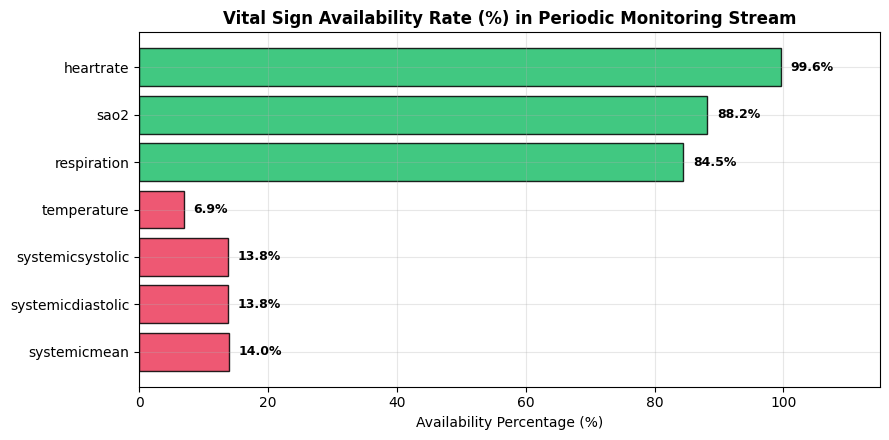

In [15]:
# Visualize Vital Sign Availability Rates
vital_names = [m["Vital Sign"] for m in vital_metrics]
avail_pcts = [float(m["Availability (%)"].replace("%", "")) for m in vital_metrics]
colors = ["#20bf6b" if p > 75 else "#fa8231" if p > 20 else "#eb3b5a" for p in avail_pcts]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(vital_names[::-1], avail_pcts[::-1], color=colors[::-1], edgecolor="black", alpha=0.85)
ax.set_xlim(0, 115)
ax.set_title("Vital Sign Availability Rate (%) in Periodic Monitoring Stream", fontsize=12, fontweight="bold")
ax.set_xlabel("Availability Percentage (%)")

for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.5, bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


### Vital Sign Findings:
1. **High-Frequency Bedside Vitals:** `heartrate` (99.6%), `sao2` (88.2%), and `respiration` (84.5%) are recorded continuously via telemetry monitors.
2. **Intermittent Vitals:** `temperature` has **93.1% missingness** in the periodic table because body temperature is typically recorded every 4–8 hours rather than in high-frequency streams.
3. **Invasive Arterial Blood Pressures:** `systemicsystolic`, `systemicdiastolic`, and `systemicmean` are available in only **~13.9%** of records. This is because systemic blood pressure in this table represents invasive arterial line catheters, placed only in critically ill patients.
4. **Data Quality Artifacts:** Min values show physiological noise/artifacts (e.g., negative blood pressures such as -44 mmHg systolic, -76 mmHg diastolic, and HR of 0 bpm). These raw artifacts will be filtered in Phase 2 during data validation.


## 7. Temporal Understanding & Observation Windows

In the eICU database, time is recorded as relative minutes:
- `labresultoffset`: Minutes from ICU admission when the lab sample was collected.
- `observationoffset`: Minutes from ICU admission when the periodic vital signs were recorded.

**Temporal Anchor Reference:**
- `offset == 0`: Exact time of ICU admission.
- `offset < 0`: Pre-ICU stay period (Emergency Department, Operating Room, transfer triage).
- `0 <= offset <= 1440`: **First 24 hours of ICU stay** (our primary clinical observation window for early mortality prediction).
- `offset > 1440`: Subsequent days in the ICU stay.

We evaluate the temporal distribution of records across these windows without applying permanent filters yet.


In [16]:
# Temporal distribution calculation for Labs and Vitals
lab_pre_icu = lab.filter(pl.col("labresultoffset") < 0).height
lab_window_24h = lab.filter((pl.col("labresultoffset") >= 0) & (pl.col("labresultoffset") <= 1440)).height
lab_post_24h = lab.filter(pl.col("labresultoffset") > 1440).height

vital_pre_icu = vital.filter(pl.col("observationoffset") < 0).height
vital_window_24h = vital.filter((pl.col("observationoffset") >= 0) & (pl.col("observationoffset") <= 1440)).height
vital_post_24h = vital.filter(pl.col("observationoffset") > 1440).height

temporal_df = pl.DataFrame({
    "Observation Window": [
        "Pre-ICU (< 0 min)",
        "First 24 Hours (0 - 1440 min) [Target Window]",
        "Post 24 Hours (> 1440 min)",
        "Total Records"
    ],
    "Lab Records": [
        f"{lab_pre_icu:,} ({lab_pre_icu / lab.height * 100:.2f}%)",
        f"{lab_window_24h:,} ({lab_window_24h / lab.height * 100:.2f}%)",
        f"{lab_post_24h:,} ({lab_post_24h / lab.height * 100:.2f}%)",
        f"{lab.height:,} (100.00%)"
    ],
    "Vital Periodic Records": [
        f"{vital_pre_icu:,} ({vital_pre_icu / vital.height * 100:.2f}%)",
        f"{vital_window_24h:,} ({vital_window_24h / vital.height * 100:.2f}%)",
        f"{vital_post_24h:,} ({vital_post_24h / vital.height * 100:.2f}%)",
        f"{vital.height:,} (100.00%)"
    ]
})

print("Temporal Window Distribution (Labs vs. Vitals):")
print(temporal_df)


Temporal Window Distribution (Labs vs. Vitals):
shape: (4, 3)
┌─────────────────────────────────┬───────────────────┬────────────────────────┐
│ Observation Window              ┆ Lab Records       ┆ Vital Periodic Records │
│ ---                             ┆ ---               ┆ ---                    │
│ str                             ┆ str               ┆ str                    │
╞═════════════════════════════════╪═══════════════════╪════════════════════════╡
│ Pre-ICU (< 0 min)               ┆ 97,488 (22.43%)   ┆ 1,650 (0.10%)          │
│ First 24 Hours (0 - 1440 min) … ┆ 98,870 (22.75%)   ┆ 553,846 (33.88%)       │
│ Post 24 Hours (> 1440 min)      ┆ 238,302 (54.82%)  ┆ 1,079,464 (66.02%)     │
│ Total Records                   ┆ 434,660 (100.00%) ┆ 1,634,960 (100.00%)    │
└─────────────────────────────────┴───────────────────┴────────────────────────┘


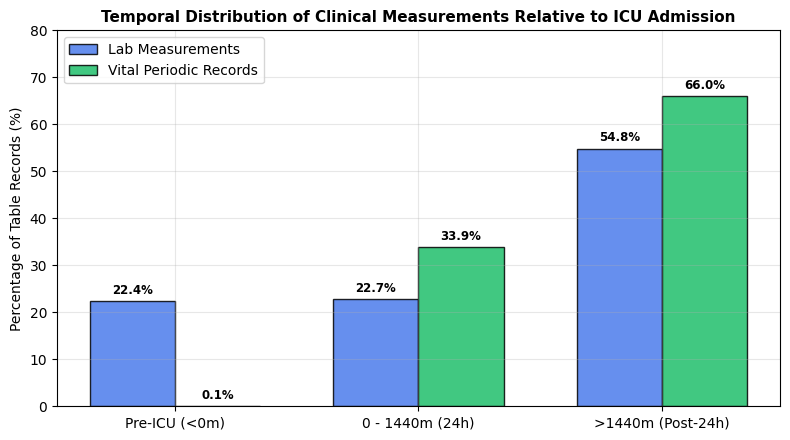

In [17]:
# Visualize Temporal Window Distributions
fig, ax = plt.subplots(figsize=(8, 4.5))

windows = ["Pre-ICU (<0m)", "0 - 1440m (24h)", ">1440m (Post-24h)"]
lab_proportions = [lab_pre_icu / lab.height * 100, lab_window_24h / lab.height * 100, lab_post_24h / lab.height * 100]
vital_proportions = [vital_pre_icu / vital.height * 100, vital_window_24h / vital.height * 100, vital_post_24h / vital.height * 100]

x = np.arange(len(windows))
width = 0.35

rects1 = ax.bar(x - width/2, lab_proportions, width, label="Lab Measurements", color="#4b7bec", edgecolor="black", alpha=0.85)
rects2 = ax.bar(x + width/2, vital_proportions, width, label="Vital Periodic Records", color="#20bf6b", edgecolor="black", alpha=0.85)

ax.set_title("Temporal Distribution of Clinical Measurements Relative to ICU Admission", fontsize=11, fontweight="bold")
ax.set_ylabel("Percentage of Table Records (%)")
ax.set_xticks(x)
ax.set_xticklabels(windows)
ax.legend(loc="upper left")
ax.set_ylim(0, 80)

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f"{height:.1f}%",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()


### Temporal Findings & Observation Window Rationale:
1. **First 24-Hour Clinical Window (0 - 1440 min):**
   - Contains 98,870 lab results (22.75%) and 553,846 vital records (33.88%).
   - Using this first 24-hour window enables early clinical risk stratification when therapeutic interventions can most effectively prevent deterioration.
2. **Pre-ICU Data (< 0 min):**
   - 22.43% of lab tests occur prior to ICU admission (e.g. in the ED or peri-operative suite). These reflect initial triage physiology.
   - Very few vitals (<0.1%) are recorded pre-ICU in `vitalPeriodic.csv`.
3. **Subsequent ICU Data (> 1440 min):**
   - 54.82% of labs and 66.02% of vitals occur after 24 hours. These must be excluded from early-warning models to prevent **lookahead bias / temporal data leakage**.


## 8. Data Leakage Identification & Feature Disqualification

In clinical machine learning, **Data Leakage** occurs when a model is trained using information that would not be available at the designated prediction time in real clinical workflow.

We explicitly identify two categories of disqualified variables:
1. **Target & Post-Outcome Variables (Discharge Leakage):** Information created at or after the ICU/hospital discharge event.
2. **Surrogate Identifiers:** Administrative database keys that lack clinical physiological meaning and risk overfitting/memorization.


In [18]:
# Define leakage and identifier columns
leakage_columns = [
    "hospitaldischargestatus",
    "unitdischargestatus",
    "hospitaldischargeoffset",
    "hospitaldischargelocation",
    "unitdischargeoffset",
    "unitdischargelocation",
    "dischargeweight"
]

identifier_columns = [
    "patientunitstayid",
    "patienthealthsystemstayid",
    "uniquepid"
]

# Build detailed explanation table
leakage_explanations = [
    ("hospitaldischargestatus", "Ground Truth Target", "Direct target variable for mortality prediction. Using it as a feature would be trivial target leakage."),
    ("unitdischargestatus", "Intermediate Target Proxy", "ICU unit discharge outcome (Alive/Expired). Highly collinear with hospital mortality; recorded at ICU departure."),
    ("hospitaldischargeoffset", "Future Temporal Variable", "Minutes to hospital discharge. Unknown at 24h; patients who die early or stay long have distinct offsets."),
    ("hospitaldischargelocation", "Post-Outcome Attribute", "Destination at discharge (e.g. 'Morgue', 'Rehabilitation', 'Home'). Directly exposes mortality/survival status."),
    ("unitdischargeoffset", "Future Temporal Variable", "Minutes to ICU unit discharge. Post-admission outcome timing unavailable during early 24h monitoring."),
    ("unitdischargelocation", "Post-Outcome Attribute", "ICU departure location (e.g. 'Floor', 'Morgue', 'Step-Down'). Informs outcome at discharge."),
    ("dischargeweight", "Post-Outcome Attribute", "Patient body weight measured at discharge. Not available during the 24-hour observation window.")
]

leakage_audit_df = pl.DataFrame({
    "Column Name": [x[0] for x in leakage_explanations],
    "Leakage Category": [x[1] for x in leakage_explanations],
    "Clinical / ML Risk Reason": [x[2] for x in leakage_explanations]
})

print("Leakage Audit - Disqualified Variables:")
print(leakage_audit_df)


Leakage Audit - Disqualified Variables:
shape: (7, 3)
┌───────────────────────────┬───────────────────────────┬─────────────────────────────────┐
│ Column Name               ┆ Leakage Category          ┆ Clinical / ML Risk Reason       │
│ ---                       ┆ ---                       ┆ ---                             │
│ str                       ┆ str                       ┆ str                             │
╞═══════════════════════════╪═══════════════════════════╪═════════════════════════════════╡
│ hospitaldischargestatus   ┆ Ground Truth Target       ┆ Direct target variable for mor… │
│ unitdischargestatus       ┆ Intermediate Target Proxy ┆ ICU unit discharge outcome (Al… │
│ hospitaldischargeoffset   ┆ Future Temporal Variable  ┆ Minutes to hospital discharge.… │
│ hospitaldischargelocation ┆ Post-Outcome Attribute    ┆ Destination at discharge (e.g.… │
│ unitdischargeoffset       ┆ Future Temporal Variable  ┆ Minutes to ICU unit discharge.… │
│ unitdischargelocation   

### Why Identifiers Must Not Become Predictors:
- `patientunitstayid`, `patienthealthsystemstayid`, `uniquepid`:
  - Administrative IDs are arbitrary surrogate integers or hash strings.
  - Using identifiers as ML predictors causes models to memorize specific patient records or hospital IDs, resulting in spurious correlations and severe overfitting that will fail to generalize to new patients or external hospitals.


## 9. Missingness & Informative Missingness in Healthcare Data

In standard machine learning, missing data is often assumed to be *Missing Completely at Random (MCAR)* and imputed blindly.

In intensive care medicine, missing data is **Missing Not at Random (MNAR)** or **Missing at Random (MAR)**:
- Lab tests and invasive lines are ordered selectively when clinical suspicion warrants them (e.g., arterial blood gases are drawn when a patient is in respiratory failure; arterial lines are inserted for septic shock).
- **The presence or absence of a measurement is itself a strong prognostic signal ("informative missingness").**
- Therefore, in SafePredict-XAI, we preserve missingness profiles to monitor data quality rather than applying naive imputation.


In [19]:
# Comprehensive missingness report across all primary tables
missing_records = []

# 1. Patient Table
for col in patient.columns:
    if patient.schema[col] == pl.String:
        null_ct = patient.filter(pl.col(col).is_null() | (pl.col(col) == "")).height
    else:
        null_ct = patient.filter(pl.col(col).is_null()).height
    
    missing_records.append({
        "Table": "patient.csv",
        "Column": col,
        "Data Type": str(patient.schema[col]),
        "Null / Blank Count": null_ct,
        "Total Rows": patient.height,
        "Missing (%)": null_ct / patient.height * 100
    })

# 2. Lab Table
for col in lab.columns:
    if lab.schema[col] == pl.String:
        null_ct = lab.filter(pl.col(col).is_null() | (pl.col(col) == "")).height
    else:
        null_ct = lab.filter(pl.col(col).is_null()).height
    
    missing_records.append({
        "Table": "lab.csv",
        "Column": col,
        "Data Type": str(lab.schema[col]),
        "Null / Blank Count": null_ct,
        "Total Rows": lab.height,
        "Missing (%)": null_ct / lab.height * 100
    })

# 3. Vital Table
for col in vital.columns:
    if vital.schema[col] == pl.String:
        null_ct = vital.filter(pl.col(col).is_null() | (pl.col(col) == "")).height
    else:
        null_ct = vital.filter(pl.col(col).is_null()).height
    
    missing_records.append({
        "Table": "vitalPeriodic.csv",
        "Column": col,
        "Data Type": str(vital.schema[col]),
        "Null / Blank Count": null_ct,
        "Total Rows": vital.height,
        "Missing (%)": null_ct / vital.height * 100
    })

missingness_full_df = pl.DataFrame(missing_records)

# Display top missing columns with non-zero missingness
top_missing = missingness_full_df.filter(pl.col("Null / Blank Count") > 0).sort("Missing (%)", descending=True)
print("Columns with Non-Zero Missingness Across All Tables:")
print(top_missing)


Columns with Non-Zero Missingness Across All Tables:
shape: (33, 6)
┌───────────────────┬────────────────────────┬───────────┬──────────────┬────────────┬─────────────┐
│ Table             ┆ Column                 ┆ Data Type ┆ Null / Blank ┆ Total Rows ┆ Missing (%) │
│ ---               ┆ ---                    ┆ ---       ┆ Count        ┆ ---        ┆ ---         │
│ str               ┆ str                    ┆ str       ┆ ---          ┆ i64        ┆ f64         │
│                   ┆                        ┆           ┆ i64          ┆            ┆             │
╞═══════════════════╪════════════════════════╪═══════════╪══════════════╪════════════╪═════════════╡
│ vitalPeriodic.csv ┆ icp                    ┆ String    ┆ 1621767      ┆ 1634960    ┆ 99.193069   │
│ vitalPeriodic.csv ┆ padiastolic            ┆ String    ┆ 1602880      ┆ 1634960    ┆ 98.037872   │
│ vitalPeriodic.csv ┆ pasystolic             ┆ String    ┆ 1602877      ┆ 1634960    ┆ 98.037689   │
│ vitalPeriodic.csv ┆ p

### Missingness Summary & Data Quality Insights:
1. **High Missingness Features:**
   - `temperature` (93.10% null in periodic stream)
   - `systemicsystolic`, `systemicdiastolic`, `systemicmean` (~86.15% null due to selective arterial line use)
   - `hospitaladmitsource` (23.57% blank)
   - `admissionweight` (7.86% null)
2. **Clean / Complete Features:**
   - Demographics (`age`, `gender`, `ethnicity`, `unittype`) have <2% missingness.
   - Lab test metadata (`labname`, `labresultoffset`) has 0% missingness; `labresult` has 0.63% missingness.
   - Routine telemetry (`heartrate`) has 0.43% missingness.


## 10. Phase 1 Conclusion & Summary

### Executive Summary of Raw Data Findings:

| Domain / Question | Finding / Metric | Architectural Decision for Next Phases |
| :--- | :--- | :--- |
| **Dataset Sizes** | • `patient.csv`: 2,520 rows $\times$ 29 cols<br>• `lab.csv`: 434,660 rows $\times$ 10 cols<br>• `vitalPeriodic.csv`: 1,634,960 rows $\times$ 19 cols | High volume handled efficiently using Polars lazy frames and vectorized expressions. |
| **Relational Linkages** | `patientunitstayid` is a 1-to-1 key in `patient.csv` and foreign key in labs and vitals. **0 orphan IDs**. 97.0% lab coverage, 94.2% vital coverage. | Merge and aggregate time-series features onto `patientunitstayid`. |
| **Cohort Hierarchy** | 1,841 unique patients $\rightarrow$ 2,174 hospital stays $\rightarrow$ 2,520 ICU stays. | Primary unit of prediction is ICU stay (`patientunitstayid`). Patient-level grouping should be considered in cross-validation splits to prevent patient leakage. |
| **Demographics & Privacy** | `age == "> 89"` in 98 stays (3.89%) due to HIPAA de-identification. Low missingness in gender (0.16%), ethnicity (1.55%), unittype (0%). | Standardize age encoding and categorize missingness in Phase 2. |
| **Target & Mortality** | **8.51% in-hospital mortality** (212 expired vs. 2,280 alive among known outcomes). 28 unrecorded stays. | Focus on PR-AUC, ROC-AUC, and calibration. Filter unlabelled stays during supervised training. |
| **Lab Characteristics** | 147 unique lab tests. Dominated by metabolic panels (glucose, potassium, sodium, creatinine, BUN) and CBCs (Hgb, Hct, WBC, platelets). | Select high-frequency, clinically meaningful lab panels for feature engineering in Phase 3. |
| **Vital Characteristics** | Telemetry vitals (HR, SpO2, Resp) are continuous (>84% present). Temperature is intermittent (93.1% null). Arterial BPs are selective (13.9% present). Outlier artifacts observed (e.g. negative BP). | Define clinical validity bounds [min, max] for physiological signals in Phase 2 validation. |
| **Temporal Window** | 22.8% of labs and 33.9% of vitals fall inside the primary 24-hour observation window ($0 \le \text{offset} \le 1440$). 22.4% of labs are pre-ICU. | In Phase 3, extract early-warning summary features strictly from the $0 \le \text{offset} \le 1440$ window. |
| **Data Leakage Risks** | 7 discharge/outcome variables identified (`hospitaldischargestatus`, `unitdischargestatus`, offsets, locations, weight) + 3 identifier columns. | Strictly exclude leakage columns from feature matrices to prevent false accuracy. |

---

### Ready for Next Step:
With data understanding complete, we proceed to **Phase 2: Validation & Cleaning** (defining clinical range bounds, standardizing categories, handling missing values, and validating data integrity).
